In [1]:
from google.colab import drive
drive.mount('/content/drive')

print("Drive mounted")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted


In [2]:
import subprocess
import sys
import os

print("Starting consolidated dependency installation...")

# Upgrade pip first to ensure it's up-to-date
try:
    print("Upgrading pip...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "pip"])
    print("pip upgraded successfully.")
except subprocess.CalledProcessError as e:
    print(f"Error upgrading pip: {e}")
    print("Continuing with installation, but consider manually updating pip if issues persist.")

# Clear pip cache to ensure fresh downloads
try:
    print("Clearing pip cache...")
    subprocess.check_call([sys.executable, "-m", "pip", "cache", "purge"])
    print("Pip cache cleared.")
except subprocess.CalledProcessError as e:
    print(f"Error clearing pip cache: {e}")

# This subprocess setup is crucial for fixing Google Colab's common `numpy` conflicts.
# The `numpy.dtype size changed` error often indicates binary incompatibility
# with pre-installed PyTorch/TorchVision when `numpy` is implicitly updated by other packages.
# By installing all core dependencies here and *avoiding* explicit `numpy` and `scipy`
# uninstallation/installation, we allow pip to resolve compatibility and rely on
# Colab's default `numpy`/`scipy` that are compatible with its `Torch`/`TorchVision` setup.
packages_to_install = [
    "albumentations==2.0.8", # Updated to the version installed later in the notebook
    "grad-cam==1.5.5", # Pinning to the version that was installed later in the notebook
    "ttach",
    "opencv-python", # Explicitly install opencv-python as used with cv2
    "matplotlib", # Explicitly install matplotlib as used for plotting
    "gradio", # Added gradio for the UI part
    "rembg[cpu]" # Re-adding rembg[cpu] to ensure onnxruntime backend is installed
]

try:
    print(f"Installing {', '.join(packages_to_install)}...")
    # Use --upgrade to ensure they are the latest available if already present
    # Use --no-cache-dir to ensure fresh download, combined with cache purge earlier
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "--no-cache-dir"] + packages_to_install)
    print("All specified dependencies installed successfully.")
except subprocess.CalledProcessError as e:
    print(f"Error during installation of core dependencies: {e}")
    print("Please check pip logs for details. Critical dependencies might be missing or incompatible.")
    sys.exit(1)

print("Dependency setup complete. You may now proceed with the rest of the notebook.")

Starting consolidated dependency installation...
Upgrading pip...
pip upgraded successfully.
Clearing pip cache...
Pip cache cleared.
Installing albumentations==2.0.8, grad-cam==1.5.5, ttach, opencv-python, matplotlib, gradio, rembg[cpu]...
All specified dependencies installed successfully.
Dependency setup complete. You may now proceed with the rest of the notebook.


In [3]:
import subprocess
import sys

# Reinstall torch and torchvision to resolve potential numpy binary incompatibility.
# This is often necessary in environments like Colab where numpy might get updated
# by other packages, leading to conflicts with pre-compiled torchvision.
print("Attempting to reinstall torch and torchvision to resolve potential numpy conflicts...")
try:
    # Use --force-reinstall to ensure they pick up the current numpy environment.
    # Use --upgrade to get the latest compatible versions.
    # The `--index-url` ensures we fetch the correct CUDA-enabled versions for Colab's GPU.
    # (Assuming CUDA 12.1, which is common for Colab's T4 GPUs. Adjust if needed for a different CUDA version).
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--force-reinstall", "--upgrade", "torch", "torchvision", "--index-url", "https://download.pytorch.org/whl/cu121"])
    print("torch and torchvision reinstalled successfully.")
except subprocess.CalledProcessError as e:
    print(f"Error reinstalling torch and torchvision: {e}")
    print("Continuing, but expect potential issues if the conflict is not resolved.")

Attempting to reinstall torch and torchvision to resolve potential numpy conflicts...
torch and torchvision reinstalled successfully.


In [4]:
import os

# Define the local SSD target directory
LOCAL_DATA_DIR = '/tmp/Datasets_367v_Cleaned_224'

# Create the target directory if it doesn't exist
!mkdir -p {LOCAL_DATA_DIR}

# Copy the dataset from Google Drive to local SSD
# The -r flag ensures recursive copying for directories
# The -L flag (or --dereference) will follow symbolic links, if any
# Using `rsync -av` is generally more robust for large directories if available
print(f"Copying dataset from Google Drive to {LOCAL_DATA_DIR}...")
# Reverting to copy the *contents* of Datasets_3c into LOCAL_DATA_DIR
!cp -r /content/drive/MyDrive/Datasets_367v_Cleaned_224/* {LOCAL_DATA_DIR}/
print("Dataset copied to local SSD.")

print(f"Contents of {LOCAL_DATA_DIR} after copy:")
!ls -F {LOCAL_DATA_DIR}

Copying dataset from Google Drive to /tmp/Datasets_367v_Cleaned_224...
Dataset copied to local SSD.
Contents of /tmp/Datasets_367v_Cleaned_224 after copy:
01_Train/  02_Val/  03_Test/


In [5]:
# JUST CHECKING
print(f"Contents of Google Drive source directory: /content/drive/MyDrive/Datasets_367v_Cleaned_224")
!ls -F /content/drive/MyDrive/Datasets_367v_Cleaned_224

Contents of Google Drive source directory: /content/drive/MyDrive/Datasets_367v_Cleaned_224
01_Train/  02_Val/  03_Test/


In [6]:
import os

# Define the local SSD target directory (assuming LOCAL_DATA_DIR is defined in cell 9c82739e)
LOCAL_DATA_DIR = '/tmp/Datasets_367v_Cleaned_224'

# Update directory paths to point to the original local SSD dataset
TRAIN_DIR = os.path.join(LOCAL_DATA_DIR, '01_Train')
VAL_DIR = os.path.join(LOCAL_DATA_DIR, '02_Val')
TEST_DIR = os.path.join(LOCAL_DATA_DIR, '03_Test')

print(f"Updated TRAIN_DIR: {TRAIN_DIR}")
print(f"Updated VAL_DIR: {VAL_DIR}")
print(f"Updated TEST_DIR: {TEST_DIR}")

Updated TRAIN_DIR: /tmp/Datasets_367v_Cleaned_224/01_Train
Updated VAL_DIR: /tmp/Datasets_367v_Cleaned_224/02_Val
Updated TEST_DIR: /tmp/Datasets_367v_Cleaned_224/03_Test


In [7]:
import sys

import os
import cv2
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.models import mobilenet_v3_large

import albumentations as A
from albumentations.pytorch import ToTensorV2

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

In [8]:
import os

# General Configuration
IMAGE_SIZE = 224
BATCH_SIZE = 32

# Ensure TRAIN_DIR is defined. It should be from cell f53f7937.
if 'TRAIN_DIR' not in globals():
    # Fallback/warning if TRAIN_DIR isn't defined, though it should be.
    print("Warning: TRAIN_DIR not found in global scope. Attempting to define from default /tmp path.")
    LOCAL_DATA_DIR = '/tmp/Datasets_367v_Cleaned_224'
    TRAIN_DIR = os.path.join(LOCAL_DATA_DIR, '01_Train')
    if not os.path.isdir(TRAIN_DIR):
        raise ValueError(f"TRAIN_DIR ({TRAIN_DIR}) is not a valid directory. Please run previous cells to ensure data is copied correctly.")

print(f"Dynamically determining CLASS_NAMES from {TRAIN_DIR}...")
# Get all entries in TRAIN_DIR that are directories, exclude hidden files
all_entries = [d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))]
CLASS_NAMES = sorted([entry for entry in all_entries if not entry.startswith('.')])

if not CLASS_NAMES:
    raise ValueError(f"No class directories found in {TRAIN_DIR}. Please check your dataset structure.")

NUM_CLASSES = len(CLASS_NAMES)

print(f"Detected CLASS_NAMES: {CLASS_NAMES}")
print(f"NUM_CLASSES: {NUM_CLASSES}")

Dynamically determining CLASS_NAMES from /tmp/Datasets_367v_Cleaned_224/01_Train...
Detected CLASS_NAMES: ['FaLan', 'Keaw_Sawoey', 'NamDokMai_Seethong', 'None']
NUM_CLASSES: 4


# **Albumentations & OpenCV Pipeline**

In [9]:
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2

# 2. Albumentations & OpenCV Pipeline

# Define the transformations using Albumentations
train_transforms = A.Compose([
    A.LongestMaxSize(max_size=IMAGE_SIZE, interpolation=cv2.INTER_LANCZOS4),
    A.PadIfNeeded(min_height=IMAGE_SIZE, min_width=IMAGE_SIZE, border_mode=cv2.BORDER_CONSTANT, value=128, p=1.0),
    A.HorizontalFlip(p=0.5),
    # A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=0.6),
    # A.RandomSunFlare(flare_roi=(0, 0, 1, 0.6), src_radius=120, p=0.4),
    # A.RandomShadow(shadow_dimension=5, p=0.4),
    # reduced augmentation
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), # Normalize after augmentations
    ToTensorV2()
])

val_test_transforms = A.Compose([
    A.LongestMaxSize(max_size=IMAGE_SIZE, interpolation=cv2.INTER_LANCZOS4),
    A.PadIfNeeded(min_height=IMAGE_SIZE, min_width=IMAGE_SIZE, border_mode=cv2.BORDER_CONSTANT, value=128, p=1.0),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

class MangoLeafDataset(Dataset):
    def __init__(self, root_dir, class_names, transform=None):
        self.root_dir = root_dir
        self.class_names = class_names
        self.transform = transform
        self.image_paths = []
        self.labels = []
        self.label_map = {name: i for i, name in enumerate(class_names)}

        for class_name in class_names:
            class_path = os.path.join(root_dir, class_name)
            # Check if directory exists before listing its contents
            if not os.path.isdir(class_path):
                raise FileNotFoundError(f"Class directory not found: {class_path}. Please check your dataset path and Google Drive mount.")
            for img_name in os.listdir(class_path):
                self.image_paths.append(os.path.join(class_path, img_name))
                self.labels.append(self.label_map[class_name])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        # Read image dynamically from disk via OpenCV
        image = cv2.imread(img_path)
        # Convert BGR to RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        return image, label, img_path

/tmp/ipykernel_17094/1607479273.py:10: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=IMAGE_SIZE, min_width=IMAGE_SIZE, border_mode=cv2.BORDER_CONSTANT, value=128, p=1.0),
/tmp/ipykernel_17094/1607479273.py:22: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=IMAGE_SIZE, min_width=IMAGE_SIZE, border_mode=cv2.BORDER_CONSTANT, value=128, p=1.0),


In [13]:
# Create Dataset and DataLoader instances
# CLASS_NAMES and NUM_CLASSES are now dynamically defined in an earlier cell (eca6b32f).
# This ensures consistency with the actual dataset directories found on disk.

train_dataset = MangoLeafDataset(TRAIN_DIR, CLASS_NAMES, train_transforms)
val_dataset = MangoLeafDataset(VAL_DIR, CLASS_NAMES, val_test_transforms)
test_dataset = MangoLeafDataset(TEST_DIR, CLASS_NAMES, val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")

Number of training samples: 1703
Number of validation samples: 236
Number of test samples: 223


In [10]:
print(f"Listing contents of the training directory: {TRAIN_DIR}")
!ls -F {TRAIN_DIR}

print(f"\nListing contents of the validation directory: {VAL_DIR}")
!ls -F {VAL_DIR}

print(f"\nListing contents of the test directory: {TEST_DIR}")
!ls -F {TEST_DIR}
# Just checking yk lol

Listing contents of the training directory: /tmp/Datasets_367v_Cleaned_224/01_Train
FaLan/	Keaw_Sawoey/  NamDokMai_Seethong/  None/

Listing contents of the validation directory: /tmp/Datasets_367v_Cleaned_224/02_Val
FaLan/	Keaw_Sawoey/  NamDokMai_Seethong/  None/

Listing contents of the test directory: /tmp/Datasets_367v_Cleaned_224/03_Test
FaLan/	Keaw_Sawoey/  NamDokMai_Seethong/  None/


In [14]:
from collections import Counter
import torch

# Define the device here so it's available for class_weights_tensor
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device for class weights: {device}")

# Get class counts from the training dataset
# train_dataset is created in cell 8e491f0c, which depends on CLASS_NAMES from eca6b32f.
# Ensure eca6b32f and 8e491f0c are executed first.
class_counts = Counter(train_dataset.labels)

# Sort class counts by class index to ensure correct order
# Handle cases where a class might have zero samples (though ideally, all classes should be represented)
sorted_class_counts = [class_counts[i] for i in range(len(CLASS_NAMES))]

# Calculate inverse class weights based on frequency
# Handle cases where count is zero to avoid ZeroDivisionError
total_samples = sum(sorted_class_counts)
base_class_weights = [total_samples / (NUM_CLASSES * (count if count > 0 else 1)) for count in sorted_class_counts]


# Define manual adjustment factors. This list needs to match the length of CLASS_NAMES.
# Initialize with neutral factors (1.0) for all classes, then apply specific adjustments.
manual_adjustment_factors = [1.0] * NUM_CLASSES

# Apply specific adjustments if the class is present
if 'Keaw_Sawoey' in CLASS_NAMES:
    manual_adjustment_factors[CLASS_NAMES.index('Keaw_Sawoey')] = 1.2 # Increase for 'Keaw_Sawoey'
if 'FaLan' in CLASS_NAMES:
    manual_adjustment_factors[CLASS_NAMES.index('FaLan')] = 1.1 # Increase for 'FaLan'
# 'NamDokMai_Seethong' and 'None' will retain the default 1.0 factor unless specified otherwise.

# Apply manual adjustments to the base weights
class_weights = [base_class_weights[i] * manual_adjustment_factors[i] for i in range(NUM_CLASSES)]

# Convert to a PyTorch tensor and move to the device
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class distribution in training dataset:", class_counts)
print("Calculated base class weights (inverse frequency):")
for i, w in enumerate(base_class_weights):
    print(f"  {CLASS_NAMES[i]}: {w:.4f}")
print("Manual adjustment factors:", manual_adjustment_factors)
print("Final adjusted class weights:", class_weights_tensor)

Using device for class weights: cpu
Class distribution in training dataset: Counter({2: 539, 0: 407, 1: 403, 3: 354})
Calculated base class weights (inverse frequency):
  FaLan: 1.0461
  Keaw_Sawoey: 1.0565
  NamDokMai_Seethong: 0.7899
  None: 1.2027
Manual adjustment factors: [1.1, 1.2, 1.0, 1.0]
Final adjusted class weights: tensor([1.1507, 1.2677, 0.7899, 1.2027])


In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import mobilenet_v3_large
from torch.optim.lr_scheduler import ReduceLROnPlateau # New import for scheduler

# CLASS_NAMES and NUM_CLASSES are now dynamically defined in cell eca6b32f.
# Ensure that cell eca6b32f has been executed before this cell.

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # Use CUDA if available
print(f"Using device: {device}")

# Load pre-trained MobileNetV3 Large model
model = mobilenet_v3_large(pretrained=True)

# Freeze all parameters initially
for param in model.parameters():
    param.requires_grad = False

# Replace the classifier head with a new one for NUM_CLASSES
# Parameters in this new head will have requires_grad=True by default
model.classifier = nn.Sequential(
    nn.Linear(model.classifier[0].in_features, 512),
    nn.Hardswish(),
    nn.Dropout(p=0.4),
    nn.Linear(512, NUM_CLASSES) # Updated to NUM_CLASSES (dynamically set)
)

# Unfreeze the very last layer of model.features (the last block in the feature extractor)
for param in model.features[-1].parameters():
    param.requires_grad = True

# Move model to the appropriate device
model.to(device)

# Define Loss Function with custom class weights
# class_weights_tensor is expected to be defined in a preceding cell (9b362c70)
loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Define Optimizer: Only update parameters that require gradients (classifier head and last feature layer)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5) # Reduced learning rate

# Add learning rate scheduler
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

print("Model configured for Partial Fine-tuning:")
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

Using device: cpu


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth
100%|██████████| 21.1M/21.1M [00:00<00:00, 113MB/s] 


Model configured for Partial Fine-tuning:
Total parameters: 3466036
Trainable parameters: 649604


# **^^ Declare Variables & Augmentation & Config Model ^^**
Some of these might actually be the same as 01 and 02. Model Config are added for training preparation

# **vv Down here is the start of 03_final_training's code vv**

In [16]:
def train_one_epoch(model, dataloader, loss_fn, optimizer, device):
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for inputs, labels, _ in tqdm(dataloader, desc="Training"): # _ to ignore image_path
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples
    return epoch_loss, epoch_accuracy

def validate_one_epoch(model, dataloader, loss_fn, device):
    model.eval()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, labels, _ in tqdm(dataloader, desc="Validation"): # _ to ignore image_path
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = loss_fn(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples
    return epoch_loss, epoch_accuracy

In [17]:
NUM_EPOCHS = 30 # You can adjust the number of epochs

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("Starting training...")
for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
    val_loss, val_acc = validate_one_epoch(model, val_loader, loss_fn, device)

    # Step the learning rate scheduler based on validation accuracy
    scheduler.step(val_acc)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

print("Training complete!")

Starting training...


Validation: 100%|██████████| 8/8 [00:11<00:00,  1.47s/it]


Epoch 1/30 - Train Loss: 1.3409, Train Acc: 0.3535 | Val Loss: 1.3034, Val Acc: 0.4619


Validation: 100%|██████████| 8/8 [00:14<00:00,  1.81s/it]


Epoch 2/30 - Train Loss: 1.2274, Train Acc: 0.5537 | Val Loss: 1.2085, Val Acc: 0.5678


...

Epoch 28/30 - Train Loss: 0.4848, Train Acc: 0.8561 | Val Loss: 0.7147, Val Acc: 0.6398


Validation: 100%|██████████| 8/8 [00:13<00:00,  1.68s/it]


Epoch 29/30 - Train Loss: 0.4802, Train Acc: 0.8509 | Val Loss: 0.7124, Val Acc: 0.6398


Validation: 100%|██████████| 8/8 [00:11<00:00,  1.46s/it]

Epoch 30/30 - Train Loss: 0.4632, Train Acc: 0.8691 | Val Loss: 0.7102, Val Acc: 0.6398
Training complete!


In [18]:
# SAVE TRAINED MODEL
MODEL_SAVE_PATH = './mobilenet_v3_mango_leaf_classifier.pth'

torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f"Model saved to {MODEL_SAVE_PATH}")

Model saved to ./mobilenet_v3_mango_leaf_classifier.pth


In [19]:
# Ensure the model architecture is defined as it was during training
# (This includes loading mobilenet_v3_large and replacing the classifier head)
model = mobilenet_v3_large(pretrained=False) # No need for pretrained weights as we're loading our own
model.classifier = nn.Sequential(
    nn.Linear(model.classifier[0].in_features, 512),
    nn.Hardswish(),
    nn.Dropout(p=0.4),
    nn.Linear(512, NUM_CLASSES) # Updated to NUM_CLASSES
)

# Load the saved state dictionary
model.load_state_dict(torch.load('./mobilenet_v3_mango_leaf_classifier.pth'))
model.to(device) # Move model to GPU if available
model.eval() # Set model to evaluation mode

print("Model loaded successfully!")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model loaded successfully!


/tmp/ipykernel_17094/3415650430.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('./mobilenet_v3_mango_leaf_classifier.pth'))


Evaluating: 100%|██████████| 7/7 [00:18<00:00,  2.71s/it]


Test Accuracy: 0.7130


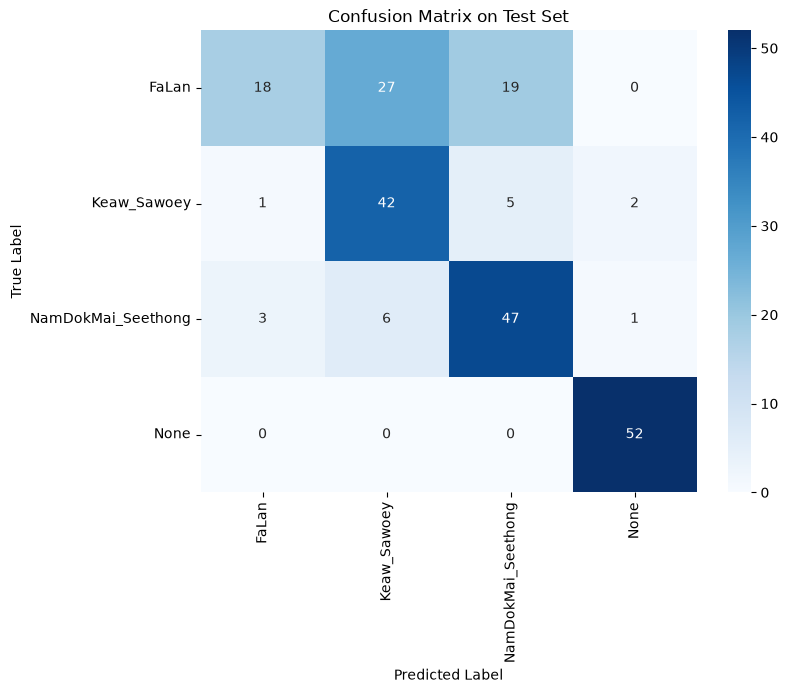


Classification Report:
                    precision    recall  f1-score   support

             FaLan       0.82      0.28      0.42        64
       Keaw_Sawoey       0.56      0.84      0.67        50
NamDokMai_Seethong       0.66      0.82      0.73        57
              None       0.95      1.00      0.97        52

          accuracy                           0.71       223
         macro avg       0.75      0.74      0.70       223
      weighted avg       0.75      0.71      0.69       223



In [25]:
# EVALUATION!!
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
# Removed pandas as it's not needed for the default string output
from tqdm import tqdm

def evaluate_model(model, dataloader, device):
    model.eval()
    all_labels = []
    all_predictions = []
    all_paths = []
    with torch.no_grad():
        for inputs, labels, paths in tqdm(dataloader, desc="Evaluating"): # Get image paths
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())
            all_paths.extend(paths) # Store paths

    accuracy = accuracy_score(all_labels, all_predictions)
    cm = confusion_matrix(all_labels, all_predictions)
    # Generate classification report as a string
    report_str = classification_report(all_labels, all_predictions, target_names=CLASS_NAMES)
    return accuracy, cm, all_labels, all_predictions, all_paths, report_str

test_accuracy, test_cm, true_labels, predictions, image_paths, classification_report_str = evaluate_model(model, test_loader, device)

print(f"Test Accuracy: {test_accuracy:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Set')
plt.show()

print("\nClassification Report:")
# Directly print the string classification report
print(classification_report_str)

# **Grad-CAM Visualizer Setup**
Defines helper functions to initialize Grad-CAM and preprocess images with a gray [128, 128, 128] background for visualization.

In [24]:
import sys

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

def get_grad_cam_heatmap(model, input_tensor, target_category, target_layers):
    # Create a GradCAM object
    # Ensuring 'target_device' is used, as 'use_cuda' is an outdated argument.
    cam = GradCAM(model=model, target_layers=target_layers)

    # Specify the target (the class whose activation we want to visualize)
    targets = [ClassifierOutputTarget(target_category)]

    # Generate the CAM heatmap
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)

    # In this example, the user has one image / batch
    grayscale_cam = grayscale_cam[0, :]
    return grayscale_cam

# Define target layers for Grad-CAM. For MobileNetV3 Large, features[-1] is often a good choice.
# This refers to the last convolutional block before the classifier.
target_layers = [model.features[-1]]

# Helper function to preprocess an image for Grad-CAM
def preprocess_image_for_cam(image_path, transform):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Create a separate transform for the image used in plotting
    # This ensures it's resized to IMAGE_SIZE while preserving aspect ratio and then padded with zeros
    plot_image_transform = A.Compose([
        A.LongestMaxSize(max_size=IMAGE_SIZE, interpolation=cv2.INTER_LANCZOS4), # Resize longest side to IMAGE_SIZE
        A.PadIfNeeded(min_height=IMAGE_SIZE, min_width=IMAGE_SIZE, border_mode=cv2.BORDER_CONSTANT, value=128, p=1.0), # Pad to make it square with gray
    ])

    # Apply the plot-specific transforms and normalize to [0, 1] for visualization
    original_img_for_plot = plot_image_transform(image=image)['image'] / 255.0
    print(f"DEBUG: Shape of original_img_for_plot for plotting: {original_img_for_plot.shape}") # Added for debugging

    # Apply the full transform for the model input (including normalization and ToTensorV2)
    preprocessed_image = transform(image=image)['image'].unsqueeze(0)

    return original_img_for_plot, preprocessed_image

#  **Display 10 examples of misclassified images with Grad-CAM**

/tmp/ipykernel_17094/3595770263.py:35: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=IMAGE_SIZE, min_width=IMAGE_SIZE, border_mode=cv2.BORDER_CONSTANT, value=128, p=1.0), # Pad to make it square with gray


DEBUG: Shape of original_img_for_plot for plotting: (224, 224, 3)
DEBUG: Shape of original_img_for_plot for plotting: (224, 224, 3)
DEBUG: Shape of original_img_for_plot for plotting: (224, 224, 3)
DEBUG: Shape of original_img_for_plot for plotting: (224, 224, 3)
DEBUG: Shape of original_img_for_plot for plotting: (224, 224, 3)
DEBUG: Shape of original_img_for_plot for plotting: (224, 224, 3)
DEBUG: Shape of original_img_for_plot for plotting: (224, 224, 3)
DEBUG: Shape of original_img_for_plot for plotting: (224, 224, 3)
DEBUG: Shape of original_img_for_plot for plotting: (224, 224, 3)
DEBUG: Shape of original_img_for_plot for plotting: (224, 224, 3)


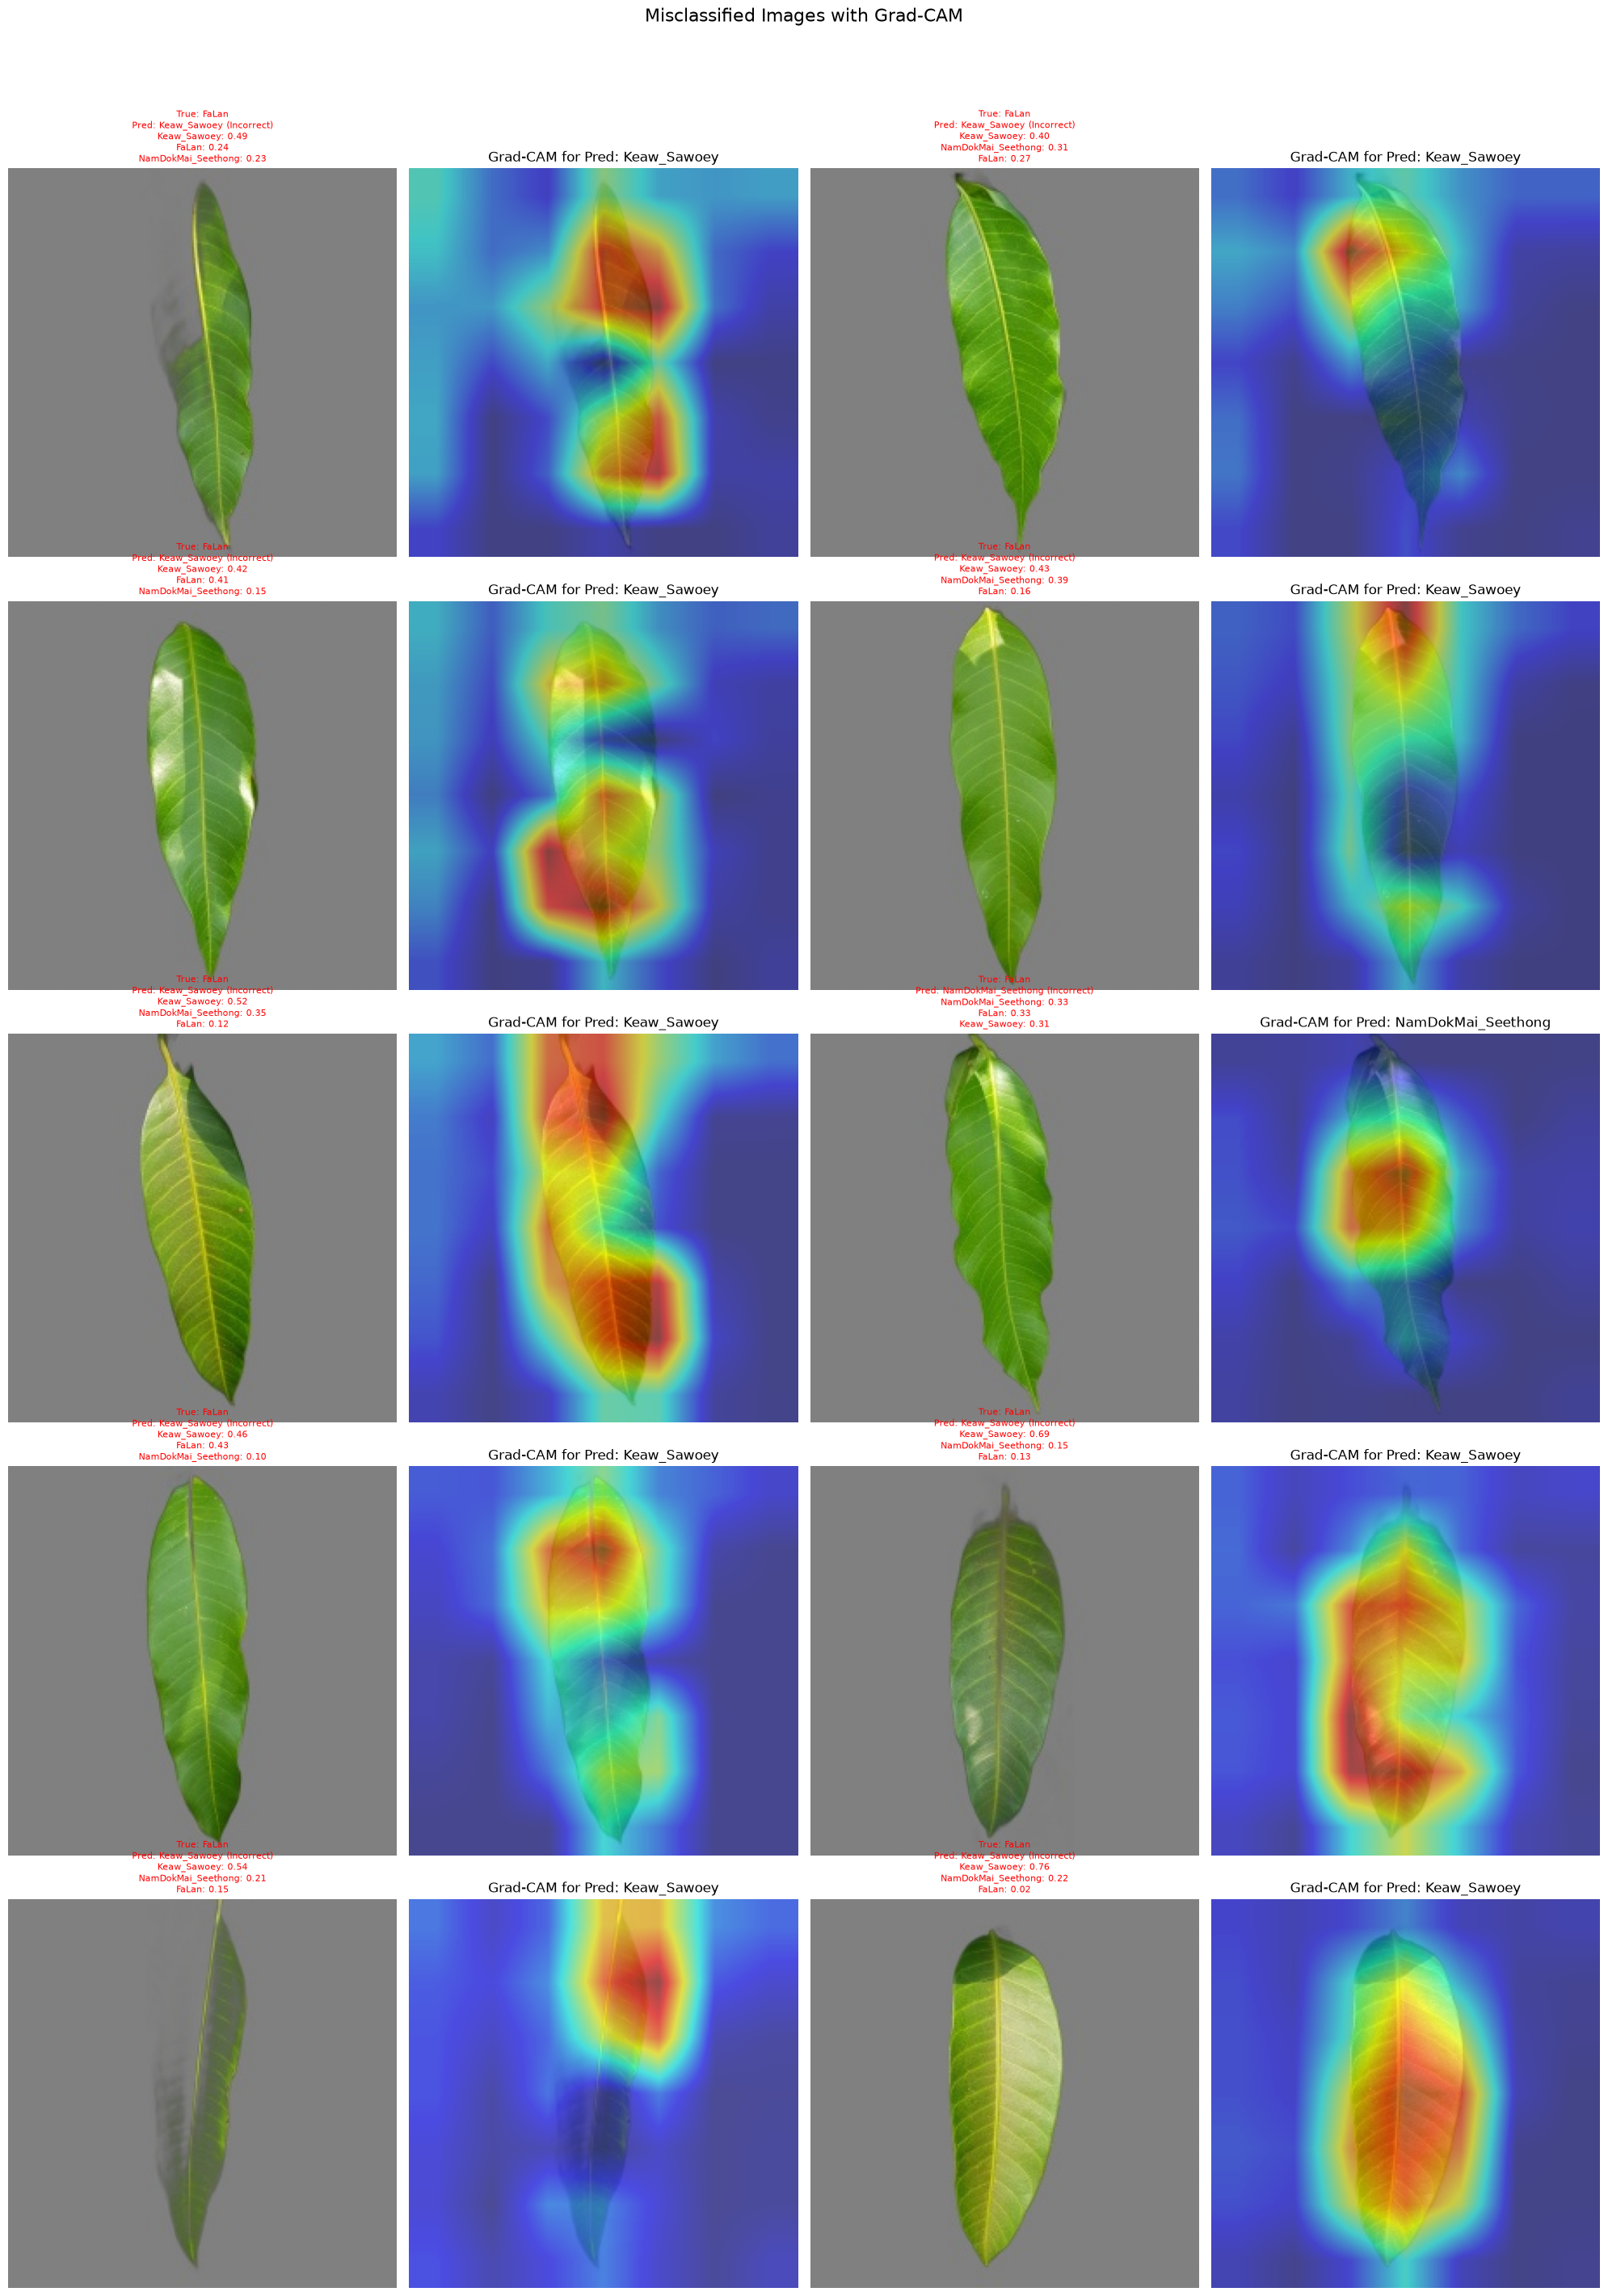

In [26]:
import torch.nn.functional as F
import numpy as np

# Calculate misclassified indices
misclassified_indices = [i for i, (true, pred) in enumerate(zip(true_labels, predictions)) if true != pred]

# Display 10 examples of misclassified images with Grad-CAM
num_display_cam = min(10, len(misclassified_indices))

if num_display_cam > 0:
    plt.figure(figsize=(20, num_display_cam * 3))
    plt.suptitle('Misclassified Images with Grad-CAM', fontsize=16)

    # Fix: Revert target_layers to point to the entire Conv2dNormActivation block
    target_layers = [model.features[-1]]

    model.eval() # Ensure model is in evaluation mode

    for i in range(num_display_cam):
        idx = misclassified_indices[i]
        img_path = image_paths[idx]
        true_label = CLASS_NAMES[true_labels[idx]]
        predicted_label = CLASS_NAMES[predictions[idx]]
        predicted_class_idx = predictions[idx]

        # Preprocess image for CAM and get original image (normalized to 0-1)
        original_img_for_plot, input_tensor_for_cam = preprocess_image_for_cam(img_path, val_test_transforms)

        # Move input_tensor_for_cam to the correct device
        input_tensor_for_cam = input_tensor_for_cam.to(device)

        # Crucial for Grad-CAM: ensure input tensor requires gradients
        input_tensor_for_cam.requires_grad_(True)

        # Get model outputs and apply softmax
        outputs = model(input_tensor_for_cam)
        probabilities = F.softmax(outputs, dim=1).squeeze().cpu().detach().numpy()

        # Get top 3 predicted probabilities
        top_prob_indices = probabilities.argsort()[-3:][::-1]
        top_prob_values = probabilities[top_prob_indices]
        top_prob_class_names = [CLASS_NAMES[k] for k in top_prob_indices]

        softmax_info = ""
        for j in range(len(top_prob_values)):
            softmax_info += f"{top_prob_class_names[j]}: {top_prob_values[j]:.2f}\n"

        # Generate Grad-CAM heatmap
        grayscale_cam = get_grad_cam_heatmap(model, input_tensor_for_cam, predicted_class_idx, target_layers)

        # Overlay the heatmap
        cam_image = show_cam_on_image(original_img_for_plot, grayscale_cam, use_rgb=True)

        plt.subplot(num_display_cam // 2 + num_display_cam % 2, 4, i * 2 + 1)
        plt.imshow(original_img_for_plot, aspect='equal')
        plt.title(f"True: {true_label}\nPred: {predicted_label} (Incorrect)\n" + softmax_info.strip(), color='red', fontsize=8)
        plt.axis('off')

        plt.subplot(num_display_cam // 2 + num_display_cam % 2, 4, i * 2 + 2)
        plt.imshow(cam_image, aspect='equal')
        plt.title(f"Grad-CAM for Pred: {predicted_label}")
        plt.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("No misclassified images to display Grad-CAM for.")

# **Learning Curve**

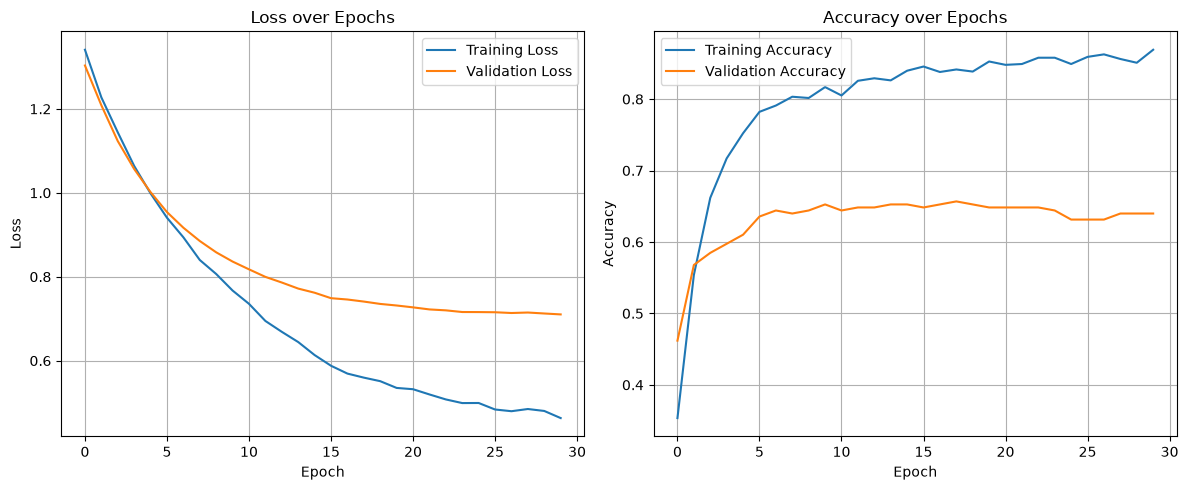

In [27]:
import matplotlib.pyplot as plt

# Plotting the learning curves
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Training Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


  # **#         END OF Final Training**